## 프로젝트 요약 및 회고
### 프로젝트 요약
- 본 프로젝트는 Transformer를 이용하여, 사용자의 질문에 대하여 챗봇이 답변(상담)하는 챗봇임.
- 주어진 데이터를 파악하고, 정제하고, 토큰화하고 증강한 후 Embeding 벡터 Transformer에 입력할 수 있게 준비하여
- positional_encoding 함수와 MultiHeadAttention, FNN, EncoderLayer, Encoder, DecoderLayer, Decoder 등의 클래스를 활용하여 
- Transformer 클래스 팩을 조립하였음
- 프로젝트는 가이드라인에 따라 진행하였으나 로컬 컴퓨터의 환경에 따라 진행이 어려운 것(mecab)은 대체 방법을 활용하였음
- 모델의 훈련은 epoch 100를 50번씩 2번에 나누어 진행
- 이는 epoch 100회를 한번에 진행할 경우 Learning Curve의 뒷부분의 변화를 파악하기 힘든 문제를 파악하기 위함임

#### 첫번째 50 epoch
  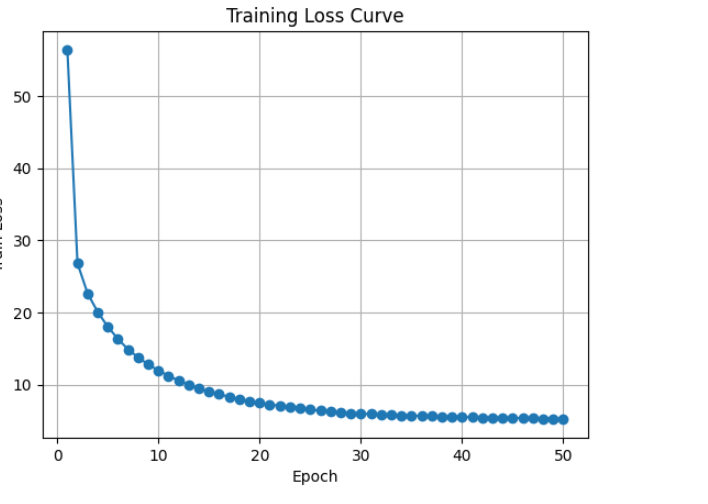
#### 두번째 50 epoch
  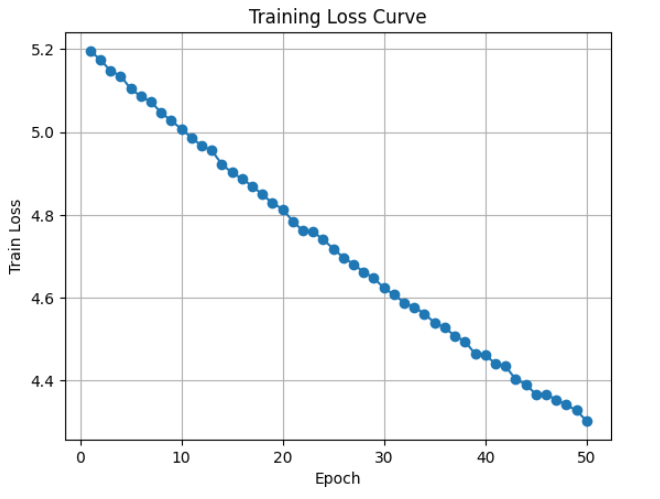

- 성능평가는 기본적으로 BLUE를 측정하였으나 본 Task가 챗봇인 점을 감안하여 ROUGE도 함께 측정하였음
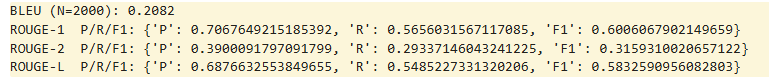
- Attention 맵은 아래와 같음
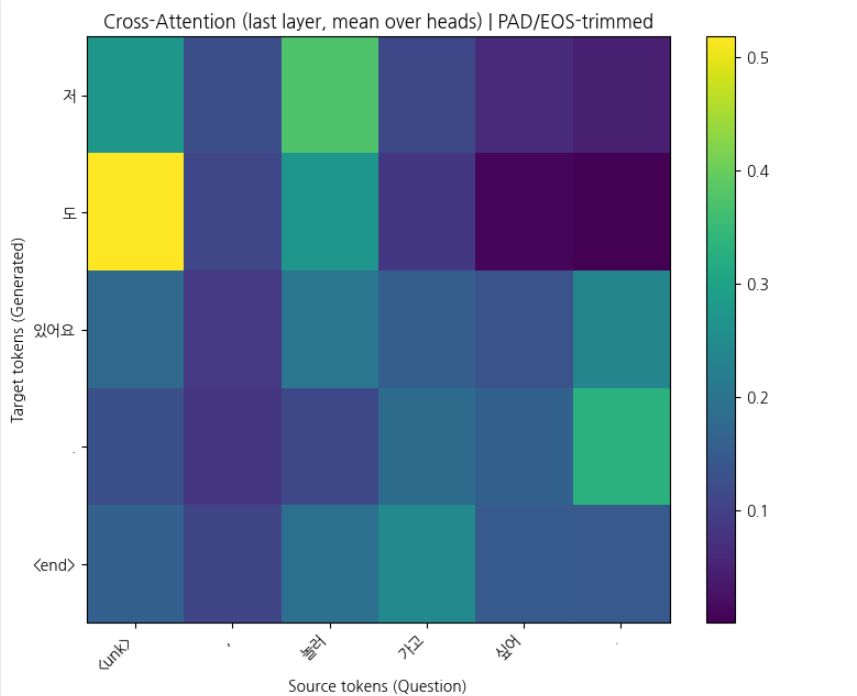


## 프로젝트 회고
---
- Transformer를 직접 대하면서 기대와 설렘이 컸다.
- 밤을 새서 코드를 돌려보고 곧 기대는 실망으로 이어졌다.
- Seq2Seq 보다 적은 데이터로 빨리 실험할 수 있어서 Seq2Seq 보다 에너지 소모는 작았지만...
- 하지만 앞으로 이어질 공부와 실험에서 성능 개선을 기대하면서 이번 프로젝트의 회고를 마친다.
- 이번 프로젝트도 C2 팀원들과 정보 공유가 큰 힘이 되었다.
- AI 프로젝트는 혼자서 하기 보다 동료들과 대화하면서 하면 재미도 있고, 성과도 올릴 수 있다는 것을 확인한 프로젝트였다.

## Task 확인 및 프로젝트 방향
---
#### Task 확인 : Transformer를 이용한 Chatbot 만들기
---
### Project Process
- step 0. 라이브러리 및 기본 설정
- step 1. 데이터 다운로드
- step 2. 데이터 정제
- step 3. 데이터 토큰화
- step 4. 데이터 증강
- step 5. 데이터 벡터화
- step 6. Transformer Pack 구성 및 모델 훈련
- step 7. 성능 측정


### Step 0. 라이브러리 및 기본 설정

In [1]:
# ============================================================
# [STEP 0 - CELL 1] Imports & Global Config
# ============================================================

import os
import re
import zipfile
from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# 최대 길이 (토큰 기준) - 필요하면 조정
MAX_LEN = 40

# Special tokens (이전 노트북의 SPM id 관례(0~3)와 맞추기 위해 이렇게 둡니다)
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

DEVICE: cuda


### Step 1. 데이터 다운로드
- 압축해제 → questions, answers

In [3]:
# ============================================================
# [STEP 1 - CELL 1] Unzip Chatbot_data.zip
# ============================================================

zip_path = Path(r"D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data.zip")
extract_dir = zip_path.parent / "Chatbot_data_unzipped"
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extracted to:", extract_dir)

# ============================================================
# [STEP 1 - CELL 2] Load ChatbotData.csv -> questions, answers
# ============================================================

# 보통 파일명이 ChatbotData.csv 인 경우가 많습니다(프로젝트 표준).
# 혹시 이름이 다르면 extract_dir 아래 CSV를 자동 탐색합니다.
csv_files = list(extract_dir.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV 파일을 찾지 못했습니다: {extract_dir}"

csv_path = csv_files[0]
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)

# 일반적으로 Q/A 컬럼이 존재합니다.
# (예외 대비) 컬럼명이 다르면 아래 후보에서 찾습니다.
q_col_candidates = ["Q", "question", "questions", "Question"]
a_col_candidates = ["A", "answer", "answers", "Answer"]

q_col = next((c for c in q_col_candidates if c in df.columns), None)
a_col = next((c for c in a_col_candidates if c in df.columns), None)

assert q_col is not None, f"질문 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"
assert a_col is not None, f"답변 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"

questions = df[q_col].astype(str).tolist()
answers   = df[a_col].astype(str).tolist()

print("questions:", len(questions), "| answers:", len(answers))
print("Q sample:", questions[0])
print("A sample:", answers[0])

Extracted to: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped
Using CSV: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped\Chatbot_data-master\ChatbotData.csv
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
Index(['Q', 'A', 'label'], dtype='str')
questions: 11823 | answers: 11823
Q sample: 12시 땡!
A sample: 하루가 또 가네요.


In [4]:
answers?

Type:        list
String form: ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.', '여행은 언제나 좋죠.', '눈살이 찌푸려지죠.', '다시 새로 사는 게 마음 편해요.', '다시 <...> 티가 나니까 눈치가 보이는 거죠!', '훔쳐보는 거 티나나봐요.', '설렜겠어요.', '잘 헤어질 수 있는 사이 여부인 거 같아요.', '도피성 결혼은 하지 않길 바라요.']
Length:      11823
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

### Step 2. 데이터 정제 
- preprocess_sentence() 구현
- 영어는 소문자로, 영문/한글/숫자/주요 특수문자만 남기고 나머지 제거
- 특수문자 범위는 과하게 넓히지 않고, 대화에서 흔한 것 위주로 구성

In [9]:
# ============================================================
# [STEP 2 - CELL 1] preprocess_sentence()  (이전 노트북 이름 유지)
# ============================================================

def preprocess_sentence(sentence: str) -> str:
    """
    - 영문자는 소문자로 변환
    - 영문/한글/숫자/주요 특수문자만 허용, 나머지는 제거
    - 토크나이저가 문장부호 처리 가능하므로 문장부호 양옆 공백 추가 등은 생략
    """
    s = str(sentence).lower().strip()

    # 허용: 한글, 영문, 숫자, 공백, 그리고 주요 특수문자(대화 데이터에 흔한 것)
    # . , ? ! ~ % @ # & ( ) [ ] { } : ; ' " - _ + = / \ |
    s = re.sub(r"[^0-9a-zA-Z가-힣\s\.\,\?\!\~\%\@\#\&\(\)\[\]\{\}\:\;\'\"\-\_\+\=\/\\\|]", "", s)

    # 공백 정리
    s = re.sub(r"\s+", " ", s).strip()
    return s

print(preprocess_sentence("안녕?? HELLO@@@ 😊 ㅎㅎㅎ"))

안녕?? hello@@@


In [11]:
#preprocess_sentence?

### Step 3. 데이터 토큰화
#### 3.1 Tokenizer getter(Mecab -> Okt fallback)
- build_corpus() + Windows Mecab 대처
- KoNLPy 문서에서 konlpy.tag.Mecab()은 Windows 미지원
- 대처 옵션: (권장) WSL2(우분투)에서 KoNLPy Mecab 사용
- Windows 네이티브에서 mecab-ko-msvc 설치(다만 KoNLPy Mecab이 “공식 지원”은 아니라서 환경마다 편차가 있음)
- 당장 진행이 목표면 Okt().morphs로 fallback(성능은 Mecab이 더 좋을 때가 많지만 파이프라인은 돌아감)
- 아래 코드는 가능하면 Mecab, 실패하면 Okt로 자동 전환합니다.

In [14]:
# ============================================================
# [STEP 3 - CELL 1] Tokenizer getter (Mecab -> Okt fallback)
# ============================================================

def get_morphs():
    """
    반환값: callable(str) -> List[str]
    우선순위:
      1) KoNLPy Mecab (WSL/리눅스 환경에서 주로 성공)  :contentReference[oaicite:5]{index=5}
      2) KoNLPy Okt fallback
    """
    try:
        from konlpy.tag import Mecab
        mecab = Mecab()  # Windows에선 일반적으로 여기서 실패 가능 :contentReference[oaicite:6]{index=6}
        print("Tokenizer: KoNLPy Mecab")
        return mecab.morphs
    except Exception as e:
        print("KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.")
        print("원인(참고):", repr(e))
        from konlpy.tag import Okt
        okt = Okt()
        print("Tokenizer: KoNLPy Okt")
        return okt.morphs

morphs = get_morphs()
print(morphs("지루하다 놀러가고 싶어"))

KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.
원인(참고): Exception('The MeCab dictionary does not exist at "/usr/local/lib/mecab/dic/mecab-ko-dic". Is the dictionary correctly installed?\nYou can also try entering the dictionary path when initializing the Mecab class: "Mecab(\'/some/dic/path\')"')
Tokenizer: KoNLPy Okt
['지루하다', '놀러', '가고', '싶어']


In [15]:
# morphs?

#### 3.2 build_corpus() 구현 + 기존 make_corpus() 이름 유지
- src/tgt 각각 정제+토큰화
- 길이 제한 초과 제거
- 중복 제거(소스는 소스대로, 타겟은 타겟대로)
- 쌍이 흐트러지지 않게 동일 인덱스를 유지하며 필터링
#### ✅ 구현 방식:
- 소스/타겟 각각 “허용 여부(keep mask)”를 만들고, 둘 다 keep인 것만 남김
- 중복 체크는 각각 seen_src, seen_tgt로 관리

In [19]:
# ============================================================
# [STEP 3 - CELL 2] make_corpus() 이름 유지
# ============================================================

def make_corpus(src_sentences, tgt_sentences, tokenizer_func, max_len=40):
    """
    반환: (src_corpus, tgt_corpus)
    - src/tgt 각각 preprocess_sentence 후 tokenizer_func 적용
    - 토큰 길이 >= max_len 인 문장 제외 (요구사항: 일정 길이 이상 제외)
    - 중복 문장 제외 (src는 src대로, tgt는 tgt대로)
    - 쌍이 흐트러지지 않도록 keep mask를 적용
    """
    assert len(src_sentences) == len(tgt_sentences)

    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    for s, t in zip(src_sentences, tgt_sentences):
        s_clean = preprocess_sentence(s)
        t_clean = preprocess_sentence(t)

        s_tokens = tokenizer_func(s_clean)
        t_tokens = tokenizer_func(t_clean)

        # 길이 제한 (>= max_len 제외)
        if len(s_tokens) >= max_len or len(t_tokens) >= max_len:
            continue

        # 중복 제거 (각각 따로)
        s_key = " ".join(s_tokens)
        t_key = " ".join(t_tokens)

        if s_key in seen_src:
            continue
        if t_key in seen_tgt:
            continue

        seen_src.add(s_key)
        seen_tgt.add(t_key)

        src_corpus.append(s_tokens)
        tgt_corpus.append(t_tokens)

    return src_corpus, tgt_corpus

In [21]:
# ============================================================
# [STEP 3 - CELL 3] build_corpus() (프로젝트 요구 이름 추가 제공)
# - 내부적으로 make_corpus를 호출하여 "기존 이름 유지" + "과제 요구 충족"
# ============================================================

def build_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=40):
    return make_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=max_len)

que_corpus, ans_corpus = build_corpus(questions, answers, morphs, max_len=MAX_LEN)

print("que_corpus:", len(que_corpus), "ans_corpus:", len(ans_corpus))
print("Q tokens sample:", que_corpus[0])
print("A tokens sample:", ans_corpus[0])

que_corpus: 7701 ans_corpus: 7701
Q tokens sample: ['12시', '땡', '!']
A tokens sample: ['하루', '가', '또', '가네요', '.']


### Step 4. Augmentation — Word2Vec + lexical_sub()
- Kyubyong/wordvectors에서 Korean(w) Word2Vec를 받아 ko.bin 확보
- gensim으로 로드해서 lexical substitution 적용
- !pip install gensim

In [23]:
# ============================================================
# [STEP 4 - SINGLE CELL] Train local Word2Vec + Safe Sample Check
# ============================================================
# pip install gensim  (안 되어 있으면 설치)

from gensim.models import Word2Vec

# Step3에서 생성된 토큰 코퍼스 사용
sentences = que_corpus + ans_corpus

# 로컬 Word2Vec 학습 (과제용 빠른 세팅)
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=1,   # ✅ 1로 설정 (vocab 누락 방지)
    workers=4,
    sg=1,          # skip-gram
    epochs=20,
    seed=SEED
)

wv = w2v_model.wv
print("Local WV ready. vocab:", len(wv.key_to_index))

# --- 안전한 sample similar 출력 ---
if sentences and len(sentences[0]) > 0:
    tok0 = sentences[0][0]
    if tok0 in wv.key_to_index:
        print("sample similar:", tok0, "=>", wv.most_similar(tok0, topn=5))
    else:
        any_tok = next(iter(wv.key_to_index.keys()))
        print("sample similar:", any_tok, "=>", wv.most_similar(any_tok, topn=5))
else:
    print("No valid tokens for sample check.")

Local WV ready. vocab: 11410
sample similar: 12시 => [('예비', 0.9839913845062256), ('맛없어', 0.9781834483146667), ('양배추', 0.9770278334617615), ('유기견', 0.9748733043670654), ('비행기', 0.9747692942619324)]


In [24]:
# ============================================================
# [STEP 4 - CELL 2] lexical_sub() (이전 노트북 이름 유지)
# ============================================================

def lexical_sub(tokens, wv_model, replace_prob=0.3, topn=10):
    """
    tokens: List[str]
    - 각 토큰에 대해 replace_prob 확률로 유사어로 치환
    - special token은 아직 넣지 않았으므로 일반 토큰만 처리
    """
    if len(tokens) == 0:
        return tokens

    new_tokens = tokens[:]
    for i, tok in enumerate(tokens):
        if random.random() > replace_prob:
            continue
        if tok not in wv_model.key_to_index:
            continue

        # 유사어 후보
        sims = wv_model.most_similar(tok, topn=topn)
        cand = [w for (w, score) in sims if w != tok]
        if len(cand) == 0:
            continue

        new_tokens[i] = random.choice(cand)

    return new_tokens

# quick test
print(que_corpus[0])
print(lexical_sub(que_corpus[0], wv, replace_prob=0.5))

['12시', '땡', '!']
['12시', '친하게', '와우']


In [26]:
# ============================================================
# [STEP 4 - CELL 3] Build augmented dataset (≈ 3x)
# 1) (aug_que, ori_ans)
# 2) (ori_que, aug_ans)
# 3) (ori_que, ori_ans)
# ============================================================

aug_que_corpus = [lexical_sub(toks, wv, replace_prob=0.3) for toks in que_corpus]
aug_ans_corpus = [lexical_sub(toks, wv, replace_prob=0.3) for toks in ans_corpus]

# 3배 구성
que_corpus_3x = que_corpus + aug_que_corpus + que_corpus
ans_corpus_3x = ans_corpus + ans_corpus + aug_ans_corpus

assert len(que_corpus_3x) == len(ans_corpus_3x)
print("3x size:", len(que_corpus_3x))

3x size: 23103


### Step 5. 데이터 벡터화 
- <start>/<end> 추가 + vocab 구축 + enc_train/dec_train
- ans_corpus에는 아직 <start>/<end>가 없으니 추가
- 챗봇은 src/tgt가 같은 언어 → vocab 공유가 유리
- 여기서는 word-level vocab(Mecab 토큰 기반)으로 진행

In [30]:
# ============================================================
# [STEP 5 - CELL 1] Add <start>/<end> to target corpus
# ============================================================

ans_corpus_3x_se = [[BOS_TOKEN] + toks + [EOS_TOKEN] for toks in ans_corpus_3x]
que_corpus_3x_se = [toks[:] for toks in que_corpus_3x]  # 질문은 보통 start/end 안 붙여도 OK

print(ans_corpus_3x_se[0][:10], "...", ans_corpus_3x_se[0][-5:])

['<start>', '하루', '가', '또', '가네요', '.', '<end>'] ... ['가', '또', '가네요', '.', '<end>']


In [31]:
# ============================================================
# [STEP 5 - CELL 2] Build shared vocab & vectorize
# ============================================================

def build_vocab(corpus_list, min_freq=2):
    """
    corpus_list: List[List[str]] 토큰 리스트들의 리스트
    반환:
      token2id, id2token
    """
    from collections import Counter
    cnt = Counter()
    for toks in corpus_list:
        cnt.update(toks)

    token2id = {
        PAD_TOKEN: PAD_ID,
        BOS_TOKEN: BOS_ID,
        EOS_TOKEN: EOS_ID,
        UNK_TOKEN: UNK_ID,
    }
    id2token = {v:k for k,v in token2id.items()}

    # 빈도 기준으로 추가
    for tok, f in cnt.most_common():
        if tok in token2id:
            continue
        if f < min_freq:
            continue
        token2id[tok] = len(token2id)
        id2token[token2id[tok]] = tok

    return token2id, id2token

# vocab은 질문+답변 전체에서 구축 (공유)
token2id, id2token = build_vocab(que_corpus_3x_se + ans_corpus_3x_se, min_freq=2)
VOCAB_SIZE = len(token2id)
print("VOCAB_SIZE:", VOCAB_SIZE)

def encode(tokens):
    return [token2id.get(t, UNK_ID) for t in tokens]

def pad_to_maxlen(ids, max_len, pad_id=PAD_ID):
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

# 벡터화
enc_train = np.array([pad_to_maxlen(encode(toks), MAX_LEN) for toks in que_corpus_3x_se], dtype=np.int64)
dec_train = np.array([pad_to_maxlen(encode(toks), MAX_LEN) for toks in ans_corpus_3x_se], dtype=np.int64)

print("enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

VOCAB_SIZE: 11414
enc_train: (23103, 40) dec_train: (23103, 40)


In [32]:
# ============================================================
# [STEP 5 - DIAG CELL] UNK/PAD/EOS 비율을 "정수 ID 배열" 기준으로 다시 측정
# - 위치: STEP 5에서 enc_train/dec_train 만든 직후 (STEP 6 전에)
# ============================================================

import numpy as np

def ratio_id(arr, _id):
    arr = np.asarray(arr)
    return float((arr == _id).sum() / max(arr.size, 1))

def eos_pos_stats(arr, eos_id=EOS_ID, pad_id=PAD_ID):
    arr = np.asarray(arr)
    eos_pos = []
    no_eos = 0
    for row in arr:
        idx = np.where(row == eos_id)[0]
        if len(idx) == 0:
            no_eos += 1
        else:
            eos_pos.append(int(idx[0]))
    eos_pos = np.array(eos_pos) if len(eos_pos) > 0 else np.array([])
    return {
        "no_eos_rows": int(no_eos),
        "eos_pos_mean": float(eos_pos.mean()) if eos_pos.size else None,
        "eos_pos_min": int(eos_pos.min()) if eos_pos.size else None,
        "eos_pos_max": int(eos_pos.max()) if eos_pos.size else None,
    }

print("=== enc_train ratios ===")
print("PAD:", ratio_id(enc_train, PAD_ID))
print("UNK:", ratio_id(enc_train, UNK_ID))
print("EOS:", ratio_id(enc_train, EOS_ID), " (참고)")

print("\n=== dec_train ratios ===")
print("PAD:", ratio_id(dec_train, PAD_ID))
print("UNK:", ratio_id(dec_train, UNK_ID))
print("EOS:", ratio_id(dec_train, EOS_ID))
print("BOS:", ratio_id(dec_train, BOS_ID))

print("\n=== dec_train EOS position stats ===")
print(eos_pos_stats(dec_train, EOS_ID, PAD_ID))

=== enc_train ratios ===
PAD: 0.8604207245812232
UNK: 0.0
EOS: 0.0  (참고)

=== dec_train ratios ===
PAD: 0.7842974938319699
UNK: 0.0
EOS: 0.025
BOS: 0.025

=== dec_train EOS position stats ===
{'no_eos_rows': 0, 'eos_pos_mean': 7.628100246721205, 'eos_pos_min': 2, 'eos_pos_max': 32}


In [43]:
# ============================================================
# [STEP 5.5 - TUNE CELL] MAX_LEN 재설정 + enc/dec 재생성 (+ 안전 점검)
# - 위치: STEP 5 - DIAG CELL 다음, STEP 6 Minimal pack 이전
# - 앞단(토큰화/사전/함수/클래스)은 그대로 유지
# - 목적: PAD 비율 폭탄(현재 enc PAD~0.86)을 줄여 학습/attention 안정화
# ============================================================

import numpy as np

# -----------------------------
# 0) 길이 분포 확인 (현재 que_corpus/ans_corpus는 "토큰 리스트"임)
# -----------------------------
q_lens = np.array([len(x) for x in que_corpus], dtype=np.int32)
a_lens = np.array([len(x) for x in ans_corpus], dtype=np.int32)

print("Q len: mean", q_lens.mean(), "p90", np.percentile(q_lens,90), "p95", np.percentile(q_lens,95), "p99", np.percentile(q_lens,99), "max", q_lens.max())
print("A len: mean", a_lens.mean(), "p90", np.percentile(a_lens,90), "p95", np.percentile(a_lens,95), "p99", np.percentile(a_lens,99), "max", a_lens.max())

# -----------------------------
# 1) MAX_LEN 자동 추천 (p95 기반 + 약간 여유)
#    - 질문/답변 중 더 긴 쪽 기준
#    - 너무 길게 잡으면 PAD 폭탄이 다시 생김
# -----------------------------
p95_len = int(max(np.percentile(q_lens,95), np.percentile(a_lens,95)))
recommended_max_len = min(max(p95_len + 8, 20), 32)   # 16~32 범위로 clamp (너무 커지지 않게) 추천p95_len = 12 이므로 + 8 -> 20임
print("\n[RECOMMEND] MAX_LEN =", recommended_max_len, "(p95 기반)")

# -----------------------------
# 2) 실제로 MAX_LEN을 바꿀지 결정 (자동으로 바꾸는 기본값)
#    - 원하시면 아래 USE_RECOMMENDED=False로 하고 직접 MAX_LEN 지정해도 됨
# -----------------------------
USE_RECOMMENDED = True
if USE_RECOMMENDED:
    MAX_LEN = recommended_max_len

print("[APPLIED] MAX_LEN =", MAX_LEN)

# -----------------------------
# 3) pad_to_maxlen 재정의 (Step5 로직 유지하면서 길이만 반영)
# -----------------------------
def pad_to_maxlen(ids, max_len, pad_id=PAD_ID):
    ids = list(ids)
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

# -----------------------------
# 4) enc/dec 다시 생성
#    - encode() / token2id / PAD_ID / BOS_ID / EOS_ID 는 Step5 것 그대로 사용
#    - enc: 질문 토큰 -> ids -> pad
#    - dec: [BOS] + 답변 토큰 ids + [EOS] -> pad
# -----------------------------
enc_all = []
dec_all = []

for q_tokens, a_tokens in zip(que_corpus, ans_corpus):
    enc_ids = pad_to_maxlen(encode(q_tokens), MAX_LEN, PAD_ID)

    # 답변: BOS + tokens + EOS (EOS 보존형)
    a_ids = encode(a_tokens)
    
    # ✅ 길면 끝부분을 잘라서라도 EOS를 반드시 넣기
    max_body = MAX_LEN - 2            # BOS, EOS 자리 확보
    a_ids = a_ids[:max_body]          # 본문만 자름
    
    dec_ids = [BOS_ID] + a_ids + [EOS_ID]
    dec_ids = pad_to_maxlen(dec_ids, MAX_LEN, PAD_ID)


    enc_all.append(enc_ids)
    dec_all.append(dec_ids)

enc_all = np.array(enc_all, dtype=np.int32)
dec_all = np.array(dec_all, dtype=np.int32)

# 기존 변수명 유지(노트북이 enc_train/dec_train을 참조하므로 그대로 덮어쓰기)
enc_train = enc_all
dec_train = dec_all

print("\n[REBUILD DONE] enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

# -----------------------------
# 5) 다시 DIAG (PAD 비율이 실제로 내려갔는지 확인)
# -----------------------------
def ratio_id(arr, _id):
    arr = np.asarray(arr)
    return float((arr == _id).sum() / max(arr.size, 1))

def eos_pos_stats(arr, eos_id=EOS_ID):
    arr = np.asarray(arr)
    eos_pos = []
    no_eos = 0
    for row in arr:
        idx = np.where(row == eos_id)[0]
        if len(idx) == 0:
            no_eos += 1
        else:
            eos_pos.append(int(idx[0]))
    eos_pos = np.array(eos_pos) if len(eos_pos) > 0 else np.array([])
    return {
        "no_eos_rows": int(no_eos),
        "eos_pos_mean": float(eos_pos.mean()) if eos_pos.size else None,
        "eos_pos_min": int(eos_pos.min()) if eos_pos.size else None,
        "eos_pos_max": int(eos_pos.max()) if eos_pos.size else None,
    }

print("\n=== (AFTER REBUILD) enc_train ratios ===")
print("PAD:", ratio_id(enc_train, PAD_ID))
print("UNK:", ratio_id(enc_train, UNK_ID))

print("\n=== (AFTER REBUILD) dec_train ratios ===")
print("PAD:", ratio_id(dec_train, PAD_ID))
print("UNK:", ratio_id(dec_train, UNK_ID))
print("EOS:", ratio_id(dec_train, EOS_ID))
print("BOS:", ratio_id(dec_train, BOS_ID))

print("\n=== (AFTER REBUILD) dec_train EOS position stats ===")
print(eos_pos_stats(dec_train, EOS_ID))

# -----------------------------
# 6) (선택) shared_fc/shared_emb 안전 점검
#    - src/tgt vocab이 같은지(같은 token2id를 쓰는지) 확인 목적
# -----------------------------
try:
    print("\n[CHECK] vocab_size:", vocab_size)
except Exception:
    pass

Q len: mean 5.583171016751071 p90 9.0 p95 11.0 p99 14.0 max 21
A len: mean 6.628100246721205 p90 10.0 p95 12.0 p99 16.0 max 31

[RECOMMEND] MAX_LEN = 20 (p95 기반)
[APPLIED] MAX_LEN = 20

[REBUILD DONE] enc_train: (7701, 20) dec_train: (7701, 20)

=== (AFTER REBUILD) enc_train ratios ===
PAD: 0.720847941825737
UNK: 0.0

=== (AFTER REBUILD) dec_train ratios ===
PAD: 0.5692961952993117
UNK: 0.0
EOS: 0.05
BOS: 0.05

=== (AFTER REBUILD) dec_train EOS position stats ===
{'no_eos_rows': 0, 'eos_pos_mean': 7.614076094013765, 'eos_pos_min': 2, 'eos_pos_max': 19}


### Step 6. 훈련하기 — 기존 Transformer 그대로 사용 (이름 유지)
- 여기부터는 이전 노트북의 Transformer/마스크/훈련 step 함수를 그대로 붙여 넣어야 함
- 아래 셀은 “챗봇 프로젝트용 하이퍼파라미터”만 조정하고,
- 클래스/함수 이름은 동일하게 유지하는 구조임

### ✅ Transformer Pack 구성
- positional_encoding, MultiHeadAttention, EncoderLayer, Encoder, DecoderLayer, Decoder, Transformer,
- generate_padding_mask, generate_lookahead_mask, generate_masks,
- loss_function, train_step

In [45]:
# ============================================================
# [STEP 6 - CELL 0] Imports + train-time globals (HPARAM)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# (Step5.5에서 이미 세팅했으면 그대로 사용)
try:
    LR
except NameError:
    LR = 1e-4

try:
    DROPOUT
except NameError:
    DROPOUT = 0.2

try:
    CLIP_NORM
except NameError:
    CLIP_NORM = 1.0

try:
    LABEL_SMOOTHING
except NameError:
    LABEL_SMOOTHING = 0.1

print("[HPARAM]", "LR=", LR, "DROPOUT=", DROPOUT, "CLIP_NORM=", CLIP_NORM, "LABEL_SMOOTHING=", LABEL_SMOOTHING)
print("[MAX_LEN]", MAX_LEN)
print("[VOCAB_SIZE]", VOCAB_SIZE)
print("[DEVICE]", device)

[HPARAM] LR= 0.0002 DROPOUT= 0.2 CLIP_NORM= 1.0 LABEL_SMOOTHING= 0.1
[MAX_LEN] 20
[VOCAB_SIZE] 11414
[DEVICE] cuda


In [47]:
# ============================================================
# [STEP 6 - CELL 1] Minimal Transformer pack (defines Transformer)
# - 기존 클래스/함수명 유지
# - 변경: loss_function(label_smoothing 적용), train_step(CLIP_NORM 반영)
# ============================================================

def positional_encoding(position, d_model):
    def get_angles(pos, i):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :]
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pe = angle_rads[np.newaxis, ...]
    return torch.tensor(pe, dtype=torch.float32)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, C = x.size()
        x = x.view(B, T, self.n_heads, self.depth).transpose(1, 2)  # (B,h,T,depth)
        return x

    def forward(self, q, k, v, mask=None, return_attn=False):
        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))

        dk = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / torch.sqrt(
            torch.tensor(dk, device=q.device, dtype=torch.float32)
        )

        # mask: keep=1, mask=0 가정
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)   # (B,h,Tq,Tk)
        attn = self.drop(attn)

        out = torch.matmul(attn, v)            # (B,h,Tq,depth)
        out = out.transpose(1, 2).contiguous() # (B,Tq,h,depth)
        B, T, _, _ = out.size()
        out = out.view(B, T, self.n_heads * self.depth)
        out = self.fc(out)

        if return_attn:
            return out, attn
        return out

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.ln1(x + self.drop(self.mha(x, x, x, mask)))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, n_heads, dropout)  # self-attn
        self.mha2 = MultiHeadAttention(d_model, n_heads, dropout)  # enc-dec
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

        self.last_cross_attn = None  # ✅ 유지

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        x = self.ln1(x + self.drop(self.mha1(x, x, x, look_mask)))

        out, attn = self.mha2(x, enc, enc, pad_mask, return_attn=True)
        self.last_cross_attn = attn  # (B,h,Tt,Ts)
        x = self.ln2(x + self.drop(out))

        x = self.ln3(x + self.drop(self.ffn(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask=None):
        B, T = x.size()
        x = self.emb(x) * torch.sqrt(torch.tensor(self.d_model, device=x.device, dtype=torch.float32))
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        B, T = x.size()
        x = self.emb(x) * torch.sqrt(torch.tensor(self.d_model, device=x.device, dtype=torch.float32))
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, enc, look_mask, pad_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared_fc=True, shared_emb=True):
        super().__init__()
        self.shared_emb = nn.Embedding(src_vocab_size, d_model) if shared_emb else None
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, src_vocab_size, pos_len, dropout, shared_emb=self.shared_emb)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, tgt_vocab_size, pos_len, dropout,
                              shared_emb=self.shared_emb if shared_emb else None)

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        if shared_fc and shared_emb:
            self.fc.weight = self.shared_emb.weight

        self.last_cross_attn = None  # ✅ 유지

    def forward(self, src, tgt_inp, enc_mask, dec_enc_mask, dec_mask):
        enc = self.encoder(src, enc_mask)
        dec = self.decoder(tgt_inp, enc, dec_mask, dec_enc_mask)

        if len(self.decoder.layers) > 0:
            self.last_cross_attn = self.decoder.layers[-1].last_cross_attn

        logits = self.fc(dec)
        return logits

def generate_padding_mask(seq):
    # keep=1, pad=0
    return (seq != PAD_ID).unsqueeze(1).unsqueeze(2).int()  # (B,1,1,T)

def generate_lookahead_mask(T):
    return torch.tril(torch.ones((T, T), dtype=torch.int32))  # (T,T)

def generate_masks(src, tgt_inp):
    enc_mask = generate_padding_mask(src)     # (B,1,1,Ts)
    dec_enc_mask = generate_padding_mask(src) # (B,1,1,Ts)

    T = tgt_inp.size(1)
    look = generate_lookahead_mask(T).to(tgt_inp.device)  # (T,T)
    look = look.unsqueeze(0).unsqueeze(0)                 # (1,1,T,T)

    dec_pad = (tgt_inp != PAD_ID).unsqueeze(1).unsqueeze(2).int() # (B,1,1,T)
    dec_mask = look * dec_pad                                     # (B,1,T,T)
    return enc_mask, dec_enc_mask, dec_mask

# ✅ PATCH: label smoothing 반영 (함수명 유지)
def loss_function(logits, tgt_out):
    B, T, V = logits.size()
    try:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=float(LABEL_SMOOTHING))
    except TypeError:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    return loss_fn(logits.reshape(B*T, V), tgt_out.reshape(B*T))

# ✅ PATCH: CLIP_NORM 반영 (함수명 유지)
def train_step(src, tgt, model, optimizer):
    model.train()
    tgt_inp = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_inp)
    enc_mask = enc_mask.to(src.device)
    dec_enc_mask = dec_enc_mask.to(src.device)
    dec_mask = dec_mask.to(src.device)

    optimizer.zero_grad()
    logits = model(src, tgt_inp, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), float(CLIP_NORM))
    optimizer.step()
    return loss

In [49]:
# ============================================================
# [STEP 6 - CELL 2] Dataset / Dataloader
# ============================================================

from torch.utils.data import Dataset, DataLoader

class ChatDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc = torch.tensor(enc, dtype=torch.long)
        self.dec = torch.tensor(dec, dtype=torch.long)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx]

BATCH_SIZE = 64
train_ds = ChatDataset(enc_train, dec_train)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("Batches:", len(train_loader))
print("enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

Batches: 121
enc_train: (7701, 20) dec_train: (7701, 20)


In [51]:
# ============================================================
# [STEP 6 - CELL 3] Build model + Optimizer
# ============================================================

n_layers = 1
d_model  = 368     # 유지 (원하면 384로 바꿔도 OK)
n_heads  = 8
d_ff     = 1024
dropout  = float(DROPOUT)
pos_len  = MAX_LEN

model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=pos_len,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=float(LR))

print("Model ready:", model.__class__.__name__)

Model ready: Transformer


Epoch 01 | loss=56.4244
Epoch 02 | loss=26.8023
Epoch 03 | loss=22.6331
Epoch 04 | loss=20.0563
Epoch 05 | loss=18.0045
Epoch 06 | loss=16.3194
Epoch 07 | loss=14.8691
Epoch 08 | loss=13.7618
Epoch 09 | loss=12.7609
Epoch 10 | loss=11.9388
Epoch 11 | loss=11.2063
Epoch 12 | loss=10.5356
Epoch 13 | loss=9.9609
Epoch 14 | loss=9.4352
Epoch 15 | loss=9.0160
Epoch 16 | loss=8.6453
Epoch 17 | loss=8.2903
Epoch 18 | loss=7.9772
Epoch 19 | loss=7.7005
Epoch 20 | loss=7.4547
Epoch 21 | loss=7.2525
Epoch 22 | loss=7.0284
Epoch 23 | loss=6.8339
Epoch 24 | loss=6.6671
Epoch 25 | loss=6.5139
Epoch 26 | loss=6.3659
Epoch 27 | loss=6.2479
Epoch 28 | loss=6.1456
Epoch 29 | loss=6.0299
Epoch 30 | loss=5.9701
Epoch 31 | loss=5.8930
Epoch 32 | loss=5.8285
Epoch 33 | loss=5.7821
Epoch 34 | loss=5.7221
Epoch 35 | loss=5.6799
Epoch 36 | loss=5.6407
Epoch 37 | loss=5.5935
Epoch 38 | loss=5.5635
Epoch 39 | loss=5.5257
Epoch 40 | loss=5.4951
Epoch 41 | loss=5.4582
Epoch 42 | loss=5.4282
Epoch 43 | loss=5.3971

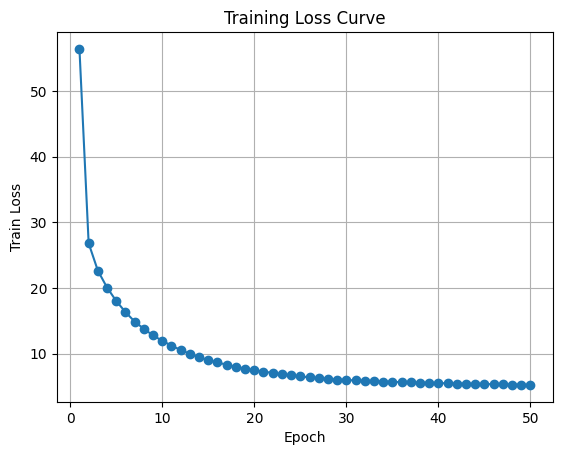

In [53]:
# ============================================================
# [STEP 6 - CELL 4] Train loop + Loss curve
# ============================================================

import matplotlib.pyplot as plt

train_losses = []

EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f}")

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

Epoch 01 | loss=5.1959
Epoch 02 | loss=5.1746
Epoch 03 | loss=5.1478
Epoch 04 | loss=5.1355
Epoch 05 | loss=5.1042
Epoch 06 | loss=5.0860
Epoch 07 | loss=5.0733
Epoch 08 | loss=5.0467
Epoch 09 | loss=5.0274
Epoch 10 | loss=5.0075
Epoch 11 | loss=4.9863
Epoch 12 | loss=4.9669
Epoch 13 | loss=4.9555
Epoch 14 | loss=4.9220
Epoch 15 | loss=4.9021
Epoch 16 | loss=4.8874
Epoch 17 | loss=4.8693
Epoch 18 | loss=4.8491
Epoch 19 | loss=4.8283
Epoch 20 | loss=4.8139
Epoch 21 | loss=4.7850
Epoch 22 | loss=4.7613
Epoch 23 | loss=4.7593
Epoch 24 | loss=4.7407
Epoch 25 | loss=4.7183
Epoch 26 | loss=4.6972
Epoch 27 | loss=4.6809
Epoch 28 | loss=4.6621
Epoch 29 | loss=4.6478
Epoch 30 | loss=4.6236
Epoch 31 | loss=4.6075
Epoch 32 | loss=4.5881
Epoch 33 | loss=4.5769
Epoch 34 | loss=4.5617
Epoch 35 | loss=4.5395
Epoch 36 | loss=4.5279
Epoch 37 | loss=4.5080
Epoch 38 | loss=4.4951
Epoch 39 | loss=4.4646
Epoch 40 | loss=4.4623
Epoch 41 | loss=4.4409
Epoch 42 | loss=4.4346
Epoch 43 | loss=4.4035
Epoch 44 | 

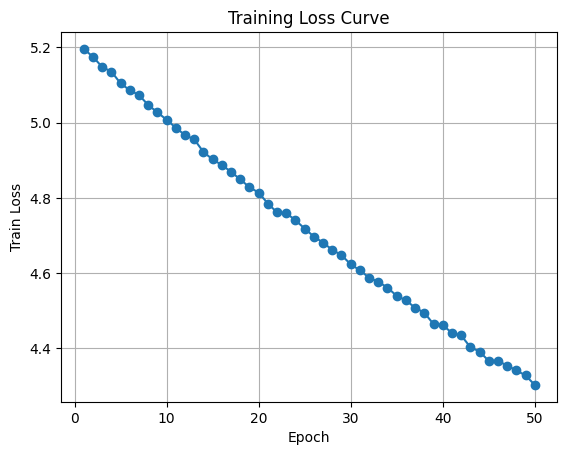

In [54]:
# ============================================================
# [STEP 6 - CELL 4] Train loop + Loss curve
# ============================================================

import matplotlib.pyplot as plt

train_losses = []

EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f}")

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [55]:
# ============================================================
# [STEP 6 - CELL 5] translate() - 반복 붕괴 방지 디코딩 (함수명 유지)
# ============================================================

import torch
import torch.nn.functional as F

def _apply_repetition_penalty(logits, generated_ids, penalty=1.25):
    if penalty is None or penalty <= 1.0:
        return logits
    for tid in set(generated_ids):
        logits[tid] /= penalty
    return logits

def _ban_repeat_ngram(logits, generated_ids, n=4):
    if n is None or n <= 1 or len(generated_ids) < (n - 1):
        return logits
    prefix = tuple(generated_ids[-(n-1):])
    banned = set()
    for i in range(len(generated_ids) - (n - 1)):
        if tuple(generated_ids[i:i+(n-1)]) == prefix:
            banned.add(generated_ids[i+(n-1)])
    if banned:
        logits[list(banned)] = -1e9
    return logits

@torch.no_grad()
def translate(tokens, model, max_len=MAX_LEN,
              temperature=0.7,
              top_k=20,
              repetition_penalty=1.25,
              no_repeat_ngram_size=4,
              min_len=3):
    model.eval()

    src_ids = pad_to_maxlen(encode(tokens), MAX_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)

        logits = model(src, ys,
                       enc_mask.to(device),
                       dec_enc_mask.to(device),
                       dec_mask.to(device))  # (1,T,V)

        next_logits = logits[0, -1, :].clone()

        if ys.size(1) < min_len:
            next_logits[EOS_ID] = -1e9

        gen_ids = ys[0].tolist()
        next_logits = _apply_repetition_penalty(next_logits, gen_ids, penalty=repetition_penalty)
        next_logits = _ban_repeat_ngram(next_logits, gen_ids, n=no_repeat_ngram_size)

        next_logits = next_logits / max(temperature, 1e-6)

        if top_k is not None and top_k > 0:
            topv, topi = torch.topk(next_logits, k=min(top_k, next_logits.size(-1)))
            probs = F.softmax(topv, dim=-1)
            next_id = topi[torch.multinomial(probs, 1)].item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()

        ys = torch.cat([ys, torch.tensor([[next_id]], dtype=torch.long, device=device)], dim=1)

        if next_id == EOS_ID:
            break

    pred_ids = ys.squeeze(0).tolist()[1:]  # drop BOS
    pred_tokens = [id2token.get(i, UNK_TOKEN) for i in pred_ids]
    return pred_tokens

In [57]:
# ============================================================
# [STEP 6 - CELL 6] Run given examples
# ============================================================

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

for s in examples:
    s_clean = preprocess_sentence(s)
    s_tokens = morphs(s_clean)
    out_tokens = translate(s_tokens, model)
    print("\nQ:", s)
    print("A:", " ".join(out_tokens))


Q: 지루하다, 놀러가고 싶어.
A: 자신 을 친구 를 내서 내서 내서 보세요 . <end>

Q: 오늘 일찍 일어났더니 피곤하다.
A: 이제 있어요 . <end>

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 이제 이 있을 거 예요 . <end>

Q: 집에 있는다는 소리야.
A: 집 말 해보세요 . <end>


In [58]:
# ============================================================
# [STEP 6 - CELL 7] (선택) 간단 sanity check
# - <start>/<end>가 dec_train에 잘 들어갔는지 확인
# ============================================================

print("BOS_ID:", BOS_ID, "EOS_ID:", EOS_ID, "PAD_ID:", PAD_ID)
print("dec_train[0][:20] =", dec_train[0][:20])
print("EOS in dec_train[0] ? ", (EOS_ID in dec_train[0]))

BOS_ID: 1 EOS_ID: 2 PAD_ID: 0
dec_train[0][:20] = [   1  236    7  103 3377    4    2    0    0    0    0    0    0    0
    0    0    0    0    0    0]
EOS in dec_train[0] ?  True


### Step 7. 성능 측정 — calculate_bleu() 적용 (이름 유지)
- 이전 노트북에 calculate_bleu()가 이미 있으니 이름은 그대로 유지하되,
- 여기서는 우리 토큰 형식(list[str])에 맞게 작동하는 버전으로 정의함

In [63]:
# ============================================================
# [STEP 7 - CELL 1] Metrics: calculate_bleu() + calculate_rouge()
# - calculate_bleu 이름 유지 (token list 기준)
# - ROUGE-1/2/L: P/R/F1 모두 출력 가능
# ============================================================

import numpy as np

def calculate_bleu(references, hypotheses, max_n=4, smooth=1e-9):
    """
    references: List[List[str]]  (정답 토큰 시퀀스들)
    hypotheses: List[List[str]]  (예측 토큰 시퀀스들)
    간단한 corpus BLEU (n-gram precision 평균 * brevity penalty)
    """
    def ngram_counts(tokens, n):
        from collections import Counter
        return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

    precisions = []
    for n in range(1, max_n+1):
        match = 0
        total = 0
        for ref, hyp in zip(references, hypotheses):
            ref_cnt = ngram_counts(ref, n)
            hyp_cnt = ngram_counts(hyp, n)
            total += sum(hyp_cnt.values())
            for g, c in hyp_cnt.items():
                match += min(c, ref_cnt.get(g, 0))
        precisions.append((match + smooth) / (total + smooth))

    ref_len = sum(len(r) for r in references)
    hyp_len = sum(len(h) for h in hypotheses)
    if hyp_len == 0:
        return 0.0
    bp = 1.0 if hyp_len > ref_len else np.exp(1 - ref_len / hyp_len)

    bleu = bp * np.exp(np.mean(np.log(precisions)))
    return float(bleu)

def _ngram_counts(tokens, n):
    from collections import Counter
    return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

def _rouge_n(ref, hyp, n=1):
    ref_ngrams = _ngram_counts(ref, n)
    hyp_ngrams = _ngram_counts(hyp, n)
    overlap = sum((ref_ngrams & hyp_ngrams).values())

    ref_total = sum(ref_ngrams.values())
    hyp_total = sum(hyp_ngrams.values())

    recall = overlap / ref_total if ref_total > 0 else 0.0
    precision = overlap / hyp_total if hyp_total > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

def _lcs_length(a, b):
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m):
        ai = a[i]
        for j in range(n):
            if ai == b[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    return dp[m][n]

def _rouge_l(ref, hyp):
    lcs = _lcs_length(ref, hyp)
    recall = lcs / len(ref) if len(ref) > 0 else 0.0
    precision = lcs / len(hyp) if len(hyp) > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

def calculate_rouge(references, hypotheses):
    """
    references: List[List[str]]
    hypotheses: List[List[str]]
    return: dict with avg rouge-1/2/l (P/R/F1)
    """
    r1_p=r1_r=r1_f=0.0
    r2_p=r2_r=r2_f=0.0
    rl_p=rl_r=rl_f=0.0
    N = max(len(hypotheses), 1)

    for ref, hyp in zip(references, hypotheses):
        p,r,f = _rouge_n(ref, hyp, n=1); r1_p+=p; r1_r+=r; r1_f+=f
        p,r,f = _rouge_n(ref, hyp, n=2); r2_p+=p; r2_r+=r; r2_f+=f
        p,r,f = _rouge_l(ref, hyp);      rl_p+=p; rl_r+=r; rl_f+=f

    return {
        "rouge1": {"P": r1_p/N, "R": r1_r/N, "F1": r1_f/N},
        "rouge2": {"P": r2_p/N, "R": r2_r/N, "F1": r2_f/N},
        "rougeL": {"P": rl_p/N, "R": rl_r/N, "F1": rl_f/N},
    }

In [65]:
# ============================================================
# [STEP 7 - CELL 2] Evaluate (BLEU + ROUGE)  ✅ 한 번만 실행
# - translate()는 Step6에서 정의된 것을 사용
# ============================================================

# 평가 샘플 수 (너무 느리면 줄이세요)
N_EVAL = 2000
eval_ques = que_corpus[:N_EVAL]
eval_ans  = ans_corpus[:N_EVAL]

def strip_special(toks):
    # 문자열 토큰 기준으로 특수토큰 제거
    specials = set()
    for x in [BOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN]:
        if isinstance(x, str):
            specials.add(x)
    return [t for t in toks if t not in specials]

references, hypotheses = [], []

for q_tokens, a_tokens in zip(eval_ques, eval_ans):
    pred_tokens = translate(q_tokens, model)

    # 정답/예측 토큰 모두 특수토큰 제거 후 비교
    references.append(strip_special(a_tokens))
    hypotheses.append(strip_special(pred_tokens))

bleu = calculate_bleu(references, hypotheses)
rouge = calculate_rouge(references, hypotheses)

print(f"BLEU (N={len(hypotheses)}): {bleu:.4f}")
print("ROUGE-1  P/R/F1:", rouge["rouge1"])
print("ROUGE-2  P/R/F1:", rouge["rouge2"])
print("ROUGE-L  P/R/F1:", rouge["rougeL"])

BLEU (N=2000): 0.2082
ROUGE-1  P/R/F1: {'P': 0.7067649215185392, 'R': 0.5656031567117085, 'F1': 0.6006067902149659}
ROUGE-2  P/R/F1: {'P': 0.3900091797091799, 'R': 0.29337146043241225, 'F1': 0.3159310020657122}
ROUGE-L  P/R/F1: {'P': 0.6876632553849655, 'R': 0.5485227331320206, 'F1': 0.5832590956082803}


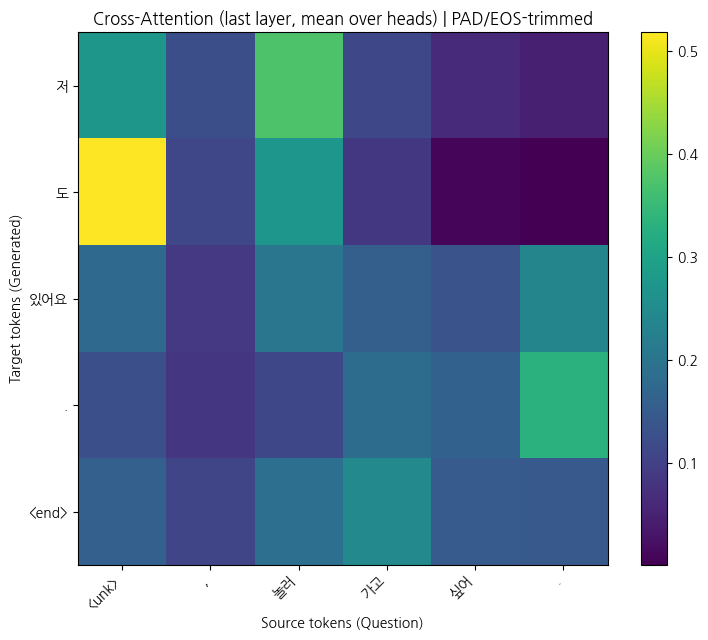

In [66]:
# ============================================================
# [STEP 7 - CELL 3] Attention Map (Cross-Attention)  ✅ FIXED
# - 함수명 plot_cross_attention 유지
# - PAD/EOS 길이 정확 슬라이싱
# - (선택) 한글 폰트까지 포함
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def _setup_korean_font():
    candidates = [
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for p in candidates:
        if os.path.exists(p):
            fp = fm.FontProperties(fname=p)
            plt.rcParams["font.family"] = fp.get_name()
            plt.rcParams["axes.unicode_minus"] = False
            return
    plt.rcParams["axes.unicode_minus"] = False

_setup_korean_font()

def _len_until_pad_id(ids, pad_id=PAD_ID):
    ids = list(ids)
    try:
        return ids.index(pad_id)
    except ValueError:
        return len(ids)

def _len_until_eos_id(ids, eos_id=EOS_ID):
    ids = list(ids)
    try:
        return ids.index(eos_id) + 1  # EOS 포함
    except ValueError:
        return len(ids)

def plot_cross_attention(question_text, drop_bos=True):
    model.eval()
    q_clean = preprocess_sentence(question_text)
    q_tokens = morphs(q_clean)

    # src ids (MAX_LEN로 패딩된 상태)
    src_ids = pad_to_maxlen(encode(q_tokens), MAX_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    # ✅ Step6의 translate 정책과 "같은 방식"으로 생성해야 맵이 일치함
    #    (Step6 translate가 sampling이므로, 여기서도 translate를 호출)
    pred_tokens = translate(q_tokens, model)  # List[str]
    pred_ids = [token2id.get(t, UNK_ID) for t in pred_tokens]  # token2id가 Step5에 있어야 함

    # translate는 BOS를 이미 drop했으니, ys는 BOS + pred_ids 형태로 복원
    ys_ids = [BOS_ID] + pred_ids
    # 혹시 EOS가 없으면 뒤에 붙여서 안정화
    if (len(ys_ids) < MAX_LEN) and (EOS_ID not in ys_ids):
        ys_ids.append(EOS_ID)
    ys_ids = ys_ids[:MAX_LEN]
    ys = torch.tensor([ys_ids], dtype=torch.long, device=device)

    # attn 캡처를 위해 1회 forward 실행
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)
    with torch.no_grad():
        _ = model(src, ys, enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))

    attn = getattr(model, "last_cross_attn", None)
    if attn is None:
        print("No attention captured. (model.last_cross_attn is None)")
        print("→ Step6 pack의 DecoderLayer/Transformer에 last_cross_attn 저장이 있는지 확인")
        return

    attn = attn[0].detach().cpu().numpy()   # (h,Tt,Ts)
    attn_mean = attn.mean(axis=0)           # (Tt,Ts)

    src_len = _len_until_pad_id(src_ids, PAD_ID)
    tgt_len = _len_until_eos_id(ys_ids, EOS_ID)

    src_show = [id2token.get(int(i), UNK_TOKEN) for i in src_ids[:src_len]]
    tgt_show = [id2token.get(int(i), UNK_TOKEN) for i in ys_ids[:tgt_len]]

    attn_show = attn_mean[:tgt_len, :src_len]

    # ✅ BOS 제거 옵션
    if drop_bos and len(tgt_show) > 0 and ys_ids[0] == BOS_ID:
        tgt_show = tgt_show[1:]
        attn_show = attn_show[1:, :]

    plt.figure(figsize=(min(12, 0.6*len(src_show)+4), min(10, 0.5*len(tgt_show)+4)))
    plt.imshow(attn_show, aspect="auto")
    plt.xticks(range(len(src_show)), src_show, rotation=45, ha="right")
    plt.yticks(range(len(tgt_show)), tgt_show)
    plt.xlabel("Source tokens (Question)")
    plt.ylabel("Target tokens (Generated)")
    plt.title("Cross-Attention (last layer, mean over heads) | PAD/EOS-trimmed")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# 예시
plot_cross_attention("지루하다, 놀러가고 싶어.")

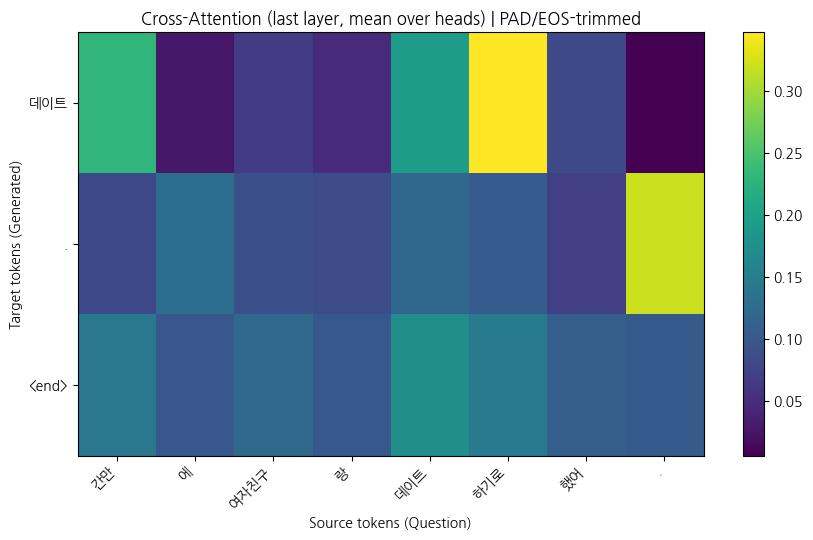

In [71]:
plot_cross_attention("간만에 여자친구랑 데이트 하기로 했어.")

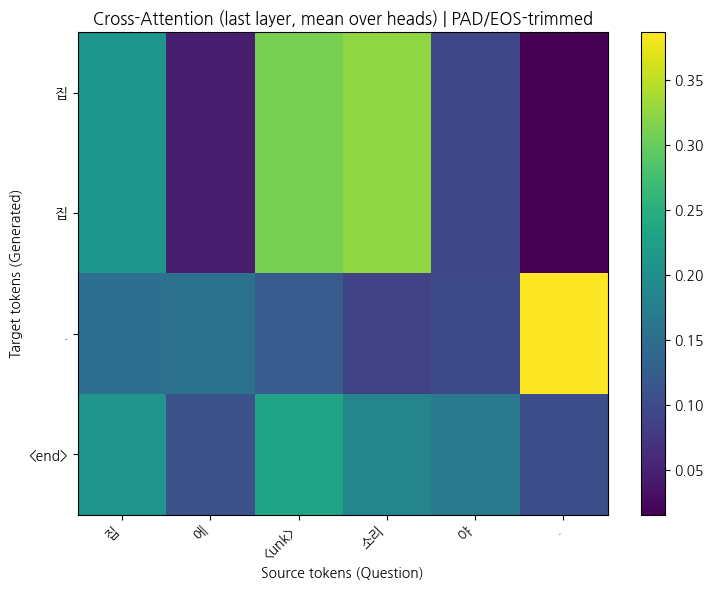

In [73]:
plot_cross_attention("집에 있는다는 소리야.")